In [36]:
# Cargamos las librerias
from skforecast.datasets import fetch_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [26]:
df = fetch_dataset(name="h2o_exog", raw=True)

╭─────────────────────────────────── h2o_exog ────────────────────────────────────╮
│ Description:                                                                    │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health   │
│ system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are │
│ simulated.                                                                      │
│                                                                                 │
│ Source:                                                                         │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd      │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,                              │
│ https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.             │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/h2o_exog.csv                                                 │
│                                                                                 │
│ Shape: 195 rows x 4 columns                                                     │
╰─────────────────────────────────────────────────────────────────────────────────╯

In [27]:
df.describe()

,y,exog_1,exog_2
count,195.000000,195.000000,195.000000
mean,0.782026,1.272981,1.478472
std,0.219447,0.148954,0.178951
min,0.361801,0.949715,1.067942
25%,0.599634,1.156923,1.353336
50%,0.761822,1.292393,1.463507
75%,0.950712,1.396324,1.599487
max,1.257238,1.534778,1.891882


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   fecha   195 non-null    object 
 1   y       195 non-null    float64
 2   exog_1  195 non-null    float64
 3   exog_2  195 non-null    float64
dtypes: float64(3), object(1)
memory usage: 6.2+ KB


In [29]:
df.head()

,fecha,y,exog_1,exog_2
0,1992-04-01,0.379808,0.958792,1.166029
1,1992-05-01,0.361801,0.951993,1.117859
2,1992-06-01,0.410534,0.952955,1.067942
3,1992-07-01,0.483389,0.958078,1.097376
4,1992-08-01,0.475463,0.956370,1.122199


In [30]:
# Aplicamos el formato correcta a la fecha
df = df.set_index("fecha")
df.index = pd.to_datetime(df.index)
df.index.freq = "MS"
df.head()

,y,exog_1,exog_2
fecha,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942
1992-07-01,0.483389,0.958078,1.097376
1992-08-01,0.475463,0.956370,1.122199


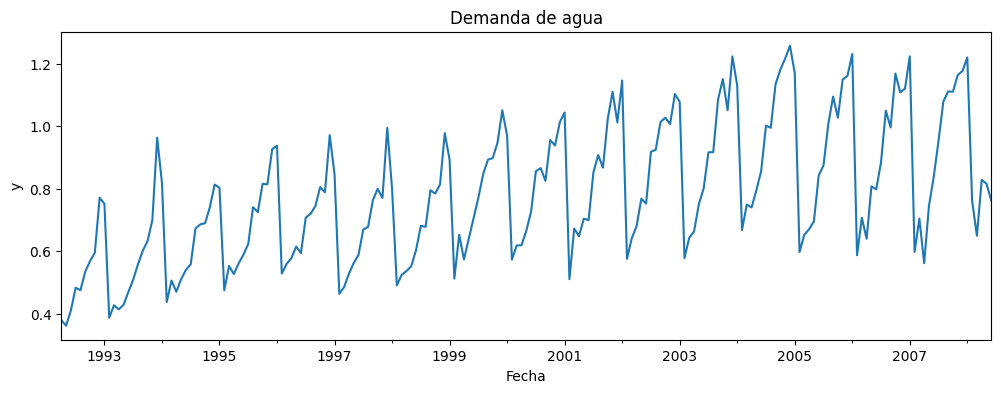

In [31]:
# Graficamos la demanda de agua
df["y"].plot(figsize=(12, 4), title="Demanda de agua")
plt.xlabel("Fecha")
plt.ylabel("y")
plt.show()

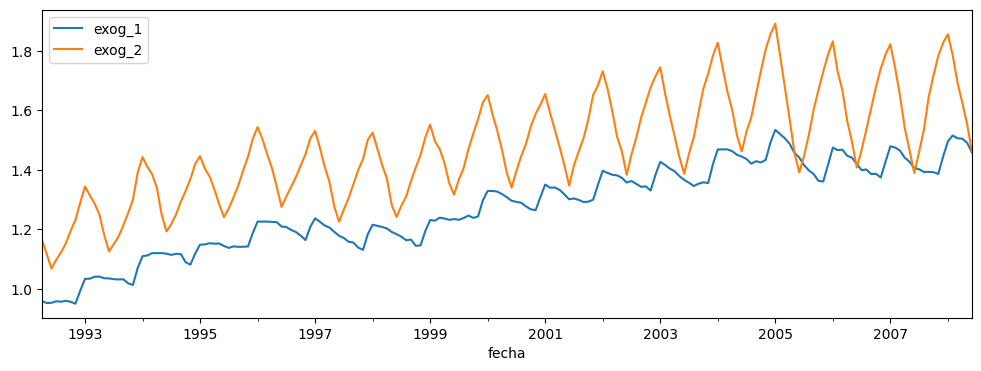

In [12]:
# Graficamos los exog
df[["exog_1", "exog_2"]].plot(figsize=(12, 4))
plt.show()

Observamos que hay un patrón estacional y va en aumento.

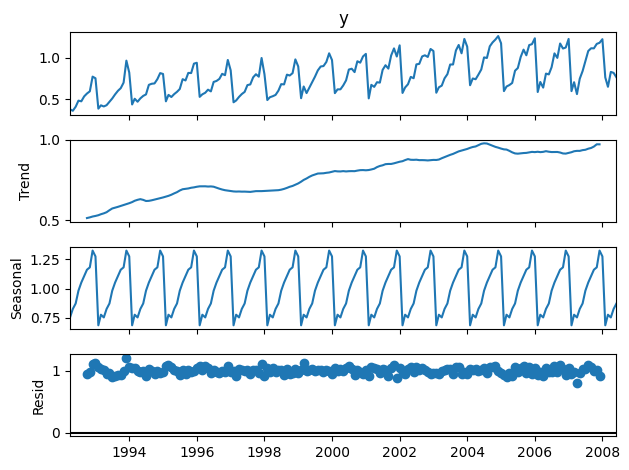

In [13]:
decomposition = seasonal_decompose(df["y"], model="multiplicative", period=12)
decomposition.plot()
plt.tight_layout()
plt.show()

Observamos como hemos dicho antes que hay una tendencia a la alta y una estacionalidad muy marcada. Por otro lado, los residuos quedan cercanos a 1 inidcando que capturó correctamente la tendencia y
la estacionalidad de la serie.

In [14]:
# Aplicamos ADF
result = adfuller(df["y"])
print("ADF Statistic:", round(result[0], 4))
print("p-value:", round(result[1], 4))

ADF Statistic: -1.518
p-value: 0.5246


p-value tras diferenciación: 0.0162


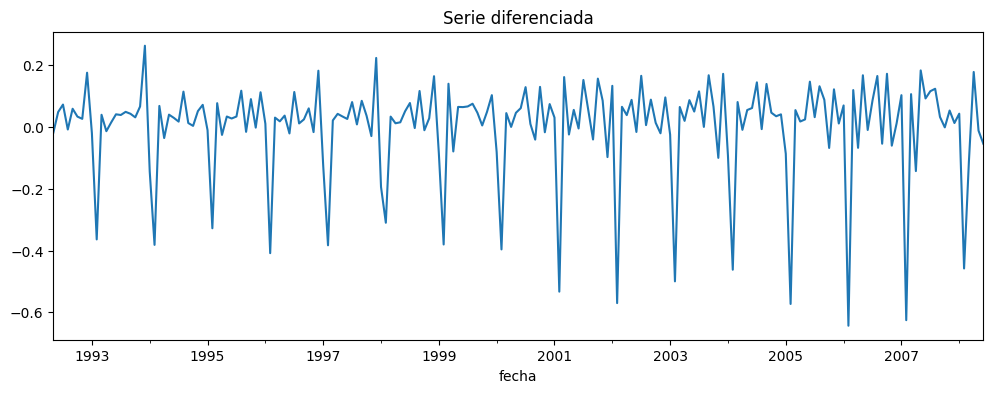

In [18]:
df_diff = df["y"].diff().dropna()
result = adfuller(df_diff)

print("p-value tras diferenciación:", round(result[1], 4))
df_diff.plot(figsize=(12, 4), title="Serie diferenciada")
plt.show()

El test de Dickey-Fuller nos dio un p-value de 0.52, confirmando que la serie
no es estacionaria. Al diferenciarla una vez el p-value bajó a 0.016, así que
con d=1 en ARIMA será suficiente.

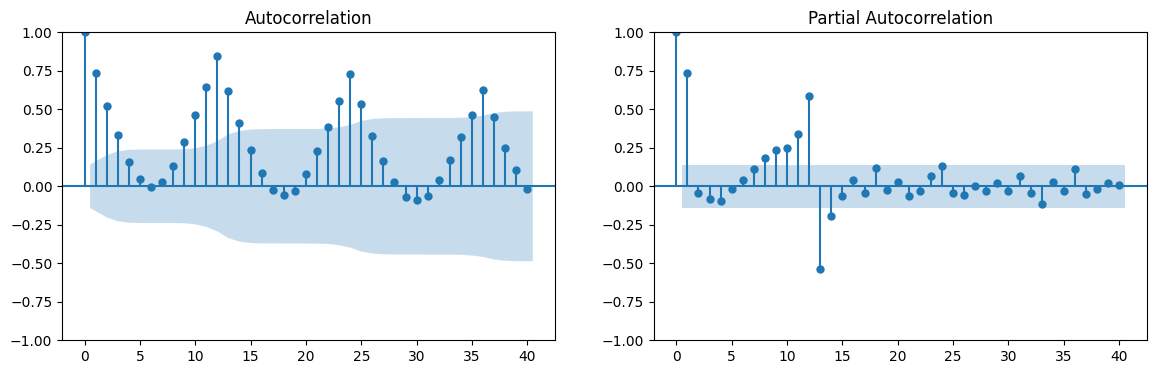

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["y"], lags=40, ax=axes[0])
plot_pacf(df["y"], lags=40, ax=axes[1])
plt.show()

In [32]:
# Buscamos los parametros para el modelo
model = SARIMAX(df["y"],
                order=(2, 1, 0),
                seasonal_order=(0, 1, 1, 12))

result = model.fit(disp=False)
print(result.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  195
Model:             SARIMAX(2, 1, 0)x(0, 1, [1], 12)   Log Likelihood                 270.808
Date:                              Sat, 11 Apr 2026   AIC                           -533.615
Time:                                      12:32:58   BIC                           -520.799
Sample:                                  04-01-1992   HQIC                          -528.420
                                       - 06-01-2008                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8558      0.065    -13.157      0.000      -0.983      -0.728
ar.L2         -0.39

In [33]:
# Train/test  - últimos 24 meses para test
train = df["y"].iloc[:-24]
test = df["y"].iloc[-24:]

# Reentrenar con train
model = SARIMAX(train, order=(2, 1, 0), seasonal_order=(0, 1, 1, 12))
result = model.fit(disp=False)
predictions = result.forecast(steps=24)

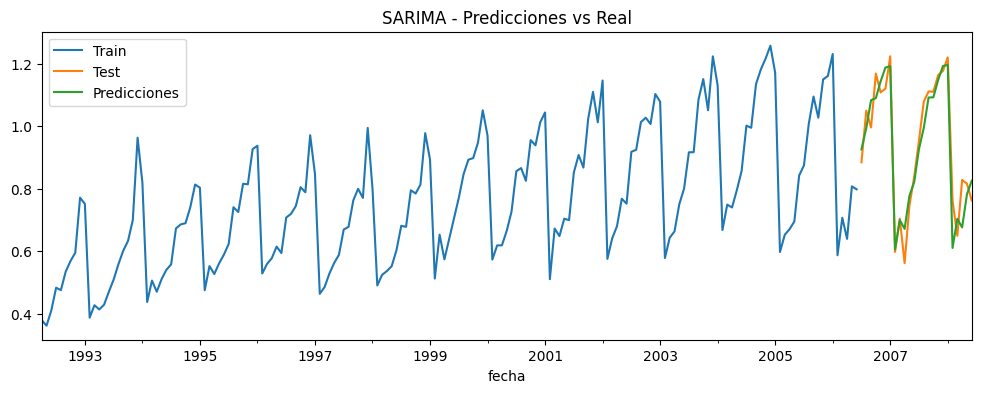

In [34]:
# Realizamos un gráfico para comparar la predicion con el train
plt.figure(figsize=(12, 4))
train.plot(label="Train")
test.plot(label="Test")
predictions.plot(label="Predicciones")
plt.legend()
plt.title("SARIMA - Predicciones vs Real")
plt.show()

Observamos que las lineas son muy similares, indicando una buena predicción

In [37]:
mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))

MAE: 0.0512
RMSE: 0.0654


El error es muy pequqeño. Dando unos buenos resultados.

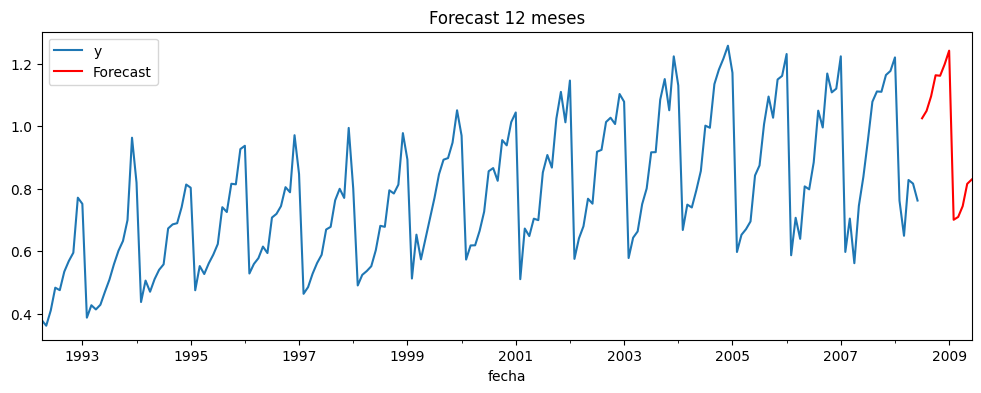

In [39]:
model_final = SARIMAX(df["y"], order=(2, 1, 0), seasonal_order=(0, 1, 1, 12))
result_final = model_final.fit(disp=False)

# Predecimos 12 meses hacia el futuro
forecast = result_final.forecast(steps=12)

plt.figure(figsize=(12, 4))
df["y"].plot()
forecast.plot(label="Forecast", color="red")
plt.legend()
plt.title("Forecast 12 meses")
plt.show()

Una de las limitaciones del ejercicio es usar solo "y" para predecir.
Se podría mejorar usando SARIMAX para incorporar las variables exógenas,
ya que pueden aportar información relevante. Además, el modelo asume que
la estacionalidad se mantendrá igual en el futuro, lo que no siempre es
realista. También se asume linealidad, cosa que
no siempre es cierta. Por último, cuanto más lejos
predecimos, más se acumulan los errores, ya que el modelo usa sus propias
predicciones como base.